In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv('../data/customer_cohort_dataset.csv')

print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn Names:", df.columns.tolist())
df.head()

Shape: (3000, 10)
Rows: 3000
Columns: 10

Column Names: ['Order_ID', 'Customer_ID', 'Order_Date', 'Product', 'Category', 'Quantity', 'Price', 'Revenue', 'Region', 'Order_Month']


,Order_ID,Customer_ID,Order_Date,Product,Category,Quantity,Price,Revenue,Region,Order_Month
0,O10000,C0072,08-07-2023,Mouse,Accessories,1,1180,1180,North,2023-07
1,O10001,C0215,27-11-2023,Mouse,Accessories,2,516,1032,East,2023-11
2,O10002,C0131,30-05-2023,Printer,Office,1,1173,1173,North,2023-05
3,O10003,C0386,11-07-2023,Phone,Electronics,2,855,1710,West,2023-07
4,O10004,C0314,22-01-2023,Monitor,Electronics,1,509,509,North,2023-01


In [4]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print("Duplicates:", df.duplicated().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== MISSING VALUES ===
Order_ID       0
Customer_ID    0
Order_Date     0
Product        0
Category       0
Quantity       0
Price          0
Revenue        0
Region         0
Order_Month    0
dtype: int64

=== DUPLICATE ROWS ===
Duplicates: 0

=== DATA TYPES ===
Order_ID       object
Customer_ID    object
Order_Date     object
Product        object
Category       object
Quantity        int64
Price           int64
Revenue         int64
Region         object
Order_Month    object
dtype: object


In [5]:
print("=== KEY STATS ===")
print("Total Orders    :", df['Order_ID'].nunique())
print("Total Customers :", df['Customer_ID'].nunique())
print("Date Range      :", df['Order_Date'].min(), "to", df['Order_Date'].max())
print("Categories      :", df['Category'].unique())
print("Products        :", df['Product'].unique())
print("Regions         :", df['Region'].unique())
print("Avg orders/customer:", round(df.groupby('Customer_ID').size().mean(), 2))

print("\n=== REVENUE STATS ===")
print(df[['Quantity','Price','Revenue']].describe())

=== KEY STATS ===
Total Orders    : 3000
Total Customers : 594
Date Range      : 01-01-2023 to 31-12-2023
Categories      : ['Accessories' 'Office' 'Electronics']
Products        : ['Mouse' 'Printer' 'Phone' 'Monitor' 'Tablet' 'Laptop' 'Keyboard'
 'Headphones']
Regions         : ['North' 'East' 'West' 'South']
Avg orders/customer: 5.05

=== REVENUE STATS ===
          Quantity        Price     Revenue
count  3000.000000  3000.000000  3000.00000
mean      2.001667   625.505333  1244.93400
std       0.817243   335.848523   869.77315
min       1.000000    50.000000    50.00000
25%       1.000000   334.000000   561.00000
50%       2.000000   621.500000  1027.00000
75%       3.000000   920.000000  1846.50000
max       3.000000  1199.000000  3591.00000


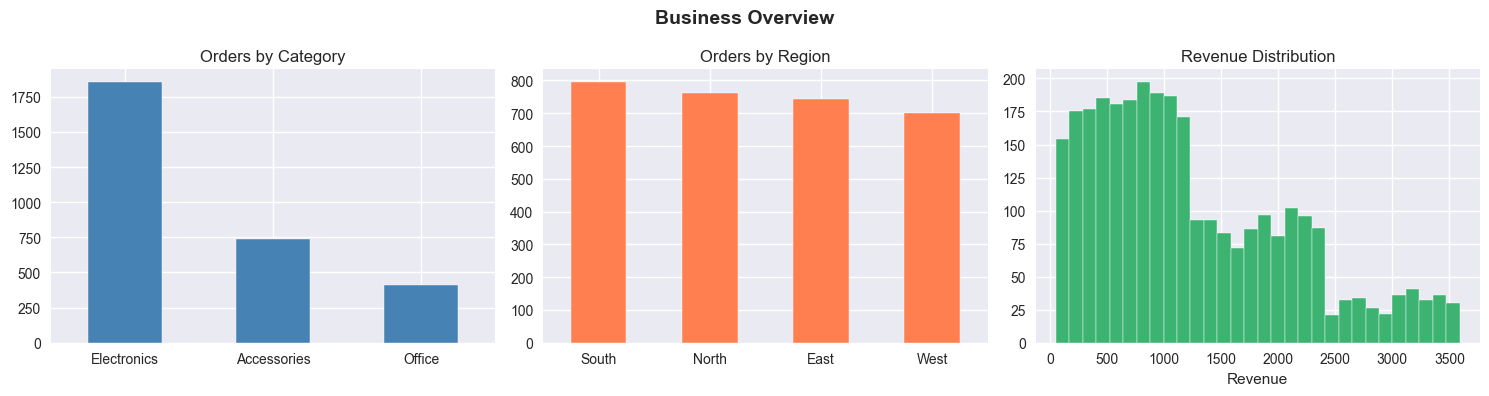

Chart saved!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Business Overview', fontsize=14, fontweight='bold')

# Orders by Category
df['Category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Orders by Category')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Orders by Region
df['Region'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Orders by Region')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

# Revenue Distribution
axes[2].hist(df['Revenue'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Revenue Distribution')
axes[2].set_xlabel('Revenue')

plt.tight_layout()
plt.savefig('../data/phase1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

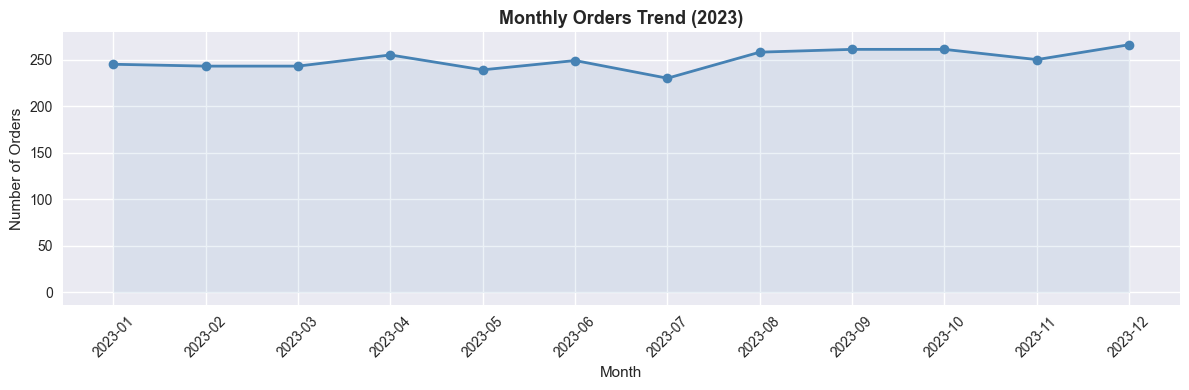

Monthly trend saved!


In [7]:
monthly = df.groupby('Order_Month')['Order_ID'].count().reset_index()
monthly.columns = ['Month', 'Orders']

plt.figure(figsize=(12, 4))
plt.plot(monthly['Month'], monthly['Orders'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly['Month'], monthly['Orders'], alpha=0.1, color='steelblue')
plt.title('Monthly Orders Trend (2023)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Monthly trend saved!")